<h1 style="font-size:300%">HOUSE PRICE PREDICTOR</h1>

This notebook is a starting point for a regression model that predicts house prices based on features of those houses. It uses the Boston House price dataset which is included in this repo as a csv file and represents prices of houses in the city of Boston in the 1970s. The data for this example is included in the git repo, so you can just clone this repo and run the notebook.

Bas S.H.T. Michielsen, 2025

![banner](https://raw.githubusercontent.com/bshtmichielsen/house_price_predictor/refs/heads/main/BANNER.jpg)

*Image by Stable Diffusion: a robot selling houses in Boston*

In [39]:
import csv, pandas, platform, os, seaborn, torch
import lightning as L
import torch.utils.data as D
import torchmetrics as M

data_path = "BostonHousing.csv"
torch.manual_seed(0)

print("Versions: python", platform.python_version(), "| torch", torch.__version__, "| lightning", L.__version__)

Versions: python 3.14.3 | torch 2.10.0+cpu | lightning 2.6.1


# Create a Dataset

The first thing to do is create a torch Dataset object from the provided csv file. Here we use pandas to load the csv file into a DataFrame and then that DataFrame is used to put the data in a TensorDataset. A TensorDataset is a structure that contains a tensor of values as features and a tensor of values as target. Of our data the last column is the target and all the other columns are the features.

In [40]:
class TabularDataset(D.TensorDataset):
    """TabularDataSet loads data from a pandas DataFrame assuming the last column is the target and all other columns are features that can be converted to float."""
    def __init__(self, dataframe: pandas.DataFrame):
        rows = dataframe.values.astype(float)
        data = torch.tensor(rows, dtype=torch.float32)
        super().__init__(data[:, :-1], data[:, -1])
    
    def num_features(self) -> int:
        return self[0][0].size()[0]

df = pandas.read_csv(data_path)
dataset = TabularDataset(df)
print("Created a TabularDataset with", dataset.num_features(), "features.")

Created a TabularDataset with 13 features.


# Sample the data

We can now use the created DataFrame to sample the data. The last column, `medv` is the target and represents the price of the house in $1000. All other columns are used as features to predict `medv` with.

In [41]:
df.sample(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
362,3.67822,0.0,18.10,0,0.770,5.362,96.2,2.1036,24,666,20.2,380.79,10.19,20.8
264,0.55007,20.0,3.97,0,0.647,7.206,91.6,1.9301,5,264,13.0,387.89,8.10,36.5
494,0.27957,0.0,9.69,0,0.585,5.926,42.6,2.3817,6,391,19.2,396.90,13.59,24.5
206,0.22969,0.0,10.59,0,0.489,6.326,52.5,4.3549,4,277,18.6,394.87,10.97,24.4


# Splitting the Dataset
To train a model, different dataset are needed, first there should be data for training purposes. However, to judge how well the model is fitted we also need data for validation and later for testing purposes. It is a common approach to split the dataset in three parts named `train`, `val` and `test` often in way that a resonably sized validation set and test set are created and the remaining data becoming the train set. For PyTorch Lightning, these three sets are then put together in something called a DataModule.

Note that you can increase `batch_size` or `num_workers` to speed up the process if you find that running this notebook is slow on your computer. However, doing so requires more CPU cores and/or more RAM so at some point you may reach a limit and things may break. The provided values of `batch_size=32` and `num_workers=0` is a safe default that is unlikely to produce errors.

In [42]:
train, val, test = D.random_split(dataset, [.6, .3, .1])
datamodule = L.LightningDataModule.from_datasets(train, val, test, batch_size=32, num_workers=0)
print("Created a DataModule with:", len(datamodule.train_dataloader().dataset), "training items,", len(datamodule.val_dataloader().dataset), "validation items and", len(datamodule.test_dataloader().dataset), "test items.")

Created a DataModule with: 304 training items, 152 validation items and 50 test items.


# Defining the Model
Of course there are many ways to define the model that is going to be trained. This example, though perhaps not the best model in the world, is rather simple and serves as an easy way of getting started with PyTorch Lightning. Here we create a simple feedforward neural network. The model consists of two layers defined in a sequential manner. First, we have a linear layer that takes in the features and transforms them into 64 nodes. This is followed by a ReLU (Rectified Linear Unit) activation function, which introduces non-linearity to the model, allowing it to learn more complex patterns. Finally, the output layer reduces the 64 nodes down to a single output, making this model suitable for regression tasks where we want to predict a single, however, continuous variable. 

In [43]:
from torch import nn

class RegressionModel(L.LightningModule):
    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.criterion = nn.MSELoss()
        self.r2 = M.R2Score()

    def forward(self, x):
        return self.model(x).view(-1)

    def training_step(self, batch):
        x, truth = batch
        out = self(x)
        return self.criterion(out, truth)
    
    def validation_step(self, batch):
        x, truth = batch
        out = self(x)
        loss = self.criterion(out, truth)
        self.log("val_loss", loss)

    def test_step(self, batch):
        x, y = batch
        out = self(x)
        self.log("test_r2", self.r2(out, y), on_step=False, on_epoch=True)

    def predict_step(self, batch):
        x, y = batch
        return self(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

model = RegressionModel(num_features=dataset.num_features())

# Training
Here we use a PyTorch Lightning Trainer to fit the model using the DataModule that we defined earlier. Internally it will iterate epochs, meaning that it will go through all train data to learn about relationships between the features and the target and then run a validation to gauge its performance which is measured in validation loss, meaning the difference between the true values and the model's predicted values. Here the assumption is that if the validation loss does no longer go down, the model is fitted as best as possible and continue training makes no improvements. We define an EarlyStopping for this that monitors when `val_loss` reaches its minimum. If so, it stops training.

In [44]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

logger = CSVLogger(save_dir=".")
stop = EarlyStopping(monitor="val_loss", mode="min")
trainer = L.Trainer(logger=logger, max_epochs=-1, callbacks=[stop], log_every_n_steps=10)
trainer.fit(model, datamodule=datamodule)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | model     | Sequential | 961    | train | 0    
1 | criterion | MSELoss    | 0      | train | 0    
2 | r2        | R2Score    | 0      | train | 0    
---------------------------------------------------------
961       Trainable params
0         Non-trainable params
961       Total params
0.004     Total estimated model params size (MB)
6         Modules in train mode
0  

c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which ma

Epoch 108: 100%|██████████| 10/10 [00:00<00:00, 59.69it/s, v_num=2] 


# Evaluation
Now that the model finished training, let's evaluate it. First we can plot the logged valiation loss and see that it has reached its minimum.

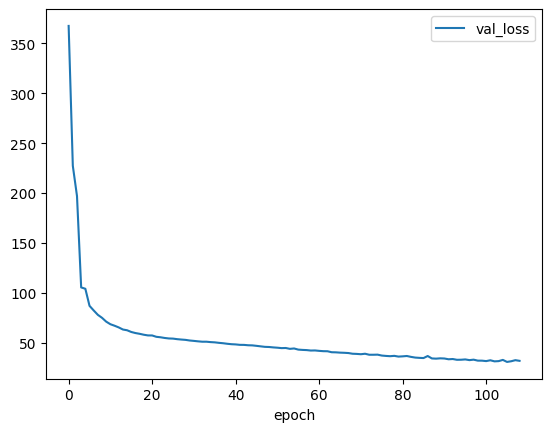

In [45]:
metrics = pandas.read_csv(os.path.join(trainer.log_dir, "metrics.csv"))
plot = metrics[["epoch", "val_loss"]].set_index("epoch").plot()

Given that the `val_loss` has flatlined (it is no longer going down), the early stop callback has stopped the training process.

Now let's run the model against the test data and get an indication for how well it is performing. A typical metric for regression models is R-squared which is the proportion of the variation in the target that is predictable from the features. In other words, how well can the target be predicted using the features. An R-squared closer to 0.0 is worse and closer to 1.0 is better.

In [46]:
score = trainer.test(model, datamodule=datamodule)

c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Testing: |          | 0/? [00:00<?, ?it/s]

Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 37.71it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_r2            0.6255152225494385
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


A regplot shows how well the predictions of the model align with the truth values. Dots on or close ot the line are good predictions whereas if dots are scatterd away from the line it indicates that our model is not doing well. The shaded area represents the expected confidence interval and dots within the shaded area are considered close to the line. Morever, this plot shows that our model does reasonably well for houses priced between 15000 and 30000 but does a bit less good for houses that are more expensive or cheaper, as dots appear farther away from the line in those price ranges.

c:\Users\qawsa\Semester4\house_price_predictor\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 210.88it/s]


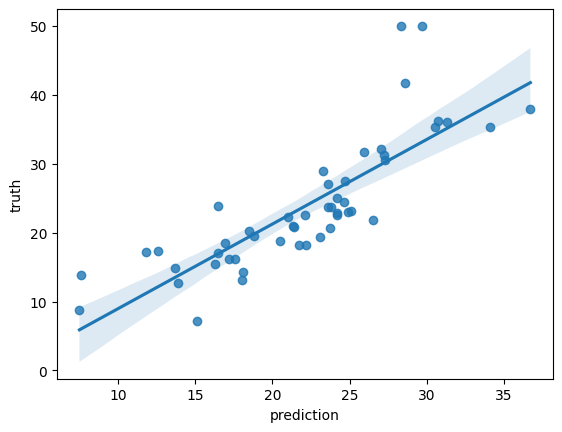

In [47]:
dataloader = datamodule.test_dataloader()
output = trainer.predict(model, dataloaders=dataloader)
predictions = torch.cat(output)
results = [[round(truth[1].item(),1), round(prediction.item(),1)] for truth, prediction in zip(dataloader.dataset, predictions)]
df = pandas.DataFrame(results, columns=["truth", "prediction"])
plot = seaborn.regplot(data=df, y="truth", x="prediction")

Here we print out all truth values, predicted values and the error (absolute difference between them) for all 50 items in the test data.

In [48]:
df["error"] = abs(df["truth"] - df["prediction"])
df

,truth,prediction,error
0,18.5,16.9,1.6
1,27.1,23.6,3.5
2,22.6,22.1,0.5
3,14.3,18.1,3.8
4,25.0,24.2,0.8
5,17.2,11.8,5.4
6,21.0,21.3,0.3
7,18.2,22.2,4.0
8,23.1,25.1,2.0
9,16.1,17.6,1.5


**Data Preprocessing with StandardScaler.**


Neural networks work best when input features are on similar scales.

Without scaling, features with larger values (like 'tax' in thousands) would dominate features with smaller values (like 'crim' which is 0-100).

Prevents numerical instability and helps the model converge faster.

Without scaling:

Large numbers dominate training

Model converges slower

Training becomes unstable

In [49]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.utils.data as D

# Split dataframe FIRST
train_df = df.sample(frac=0.6, random_state=0)
remaining_df = df.drop(train_df.index)
val_df = remaining_df.sample(frac=0.75, random_state=0)
test_df = remaining_df.drop(val_df.index)

# Separate features and target
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_val = val_df.iloc[:, :-1].values
y_val = val_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# Fit scaler ONLY on training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation & test using SAME scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors
train_dataset = D.TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_dataset = D.TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

test_dataset = D.TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

# Improve the Model



In [ ]:
from torch import nn
import torch
import torchmetrics as M
import lightning as L


class RegressionModel(L.LightningModule):
    def __init__(self, num_features):
        super().__init__()

        # Neural Network
        self.model = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Loss
        self.mse = nn.MSELoss()

        # Metrics
        self.train_r2 = M.R2Score()
        self.val_r2 = M.R2Score()
        self.test_r2 = M.R2Score()

        self.test_rmse = M.MeanSquaredError(squared=False)

    def forward(self, x):
        return self.model(x).view(-1)

    # ---------------------
    # Training
    # ---------------------
    def training_step(self, batch, batch_idx):
        x, y = batch
        y = y.float()

        preds = self(x)
        loss = self.mse(preds, y)

        self.train_r2.update(preds, y)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.log("train_r2", self.train_r2.compute(), prog_bar=True)
        self.train_r2.reset()

    # ---------------------
    # Validation
    # ---------------------
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y = y.float()

        preds = self(x)
        loss = self.mse(preds, y)

        self.val_r2.update(preds, y)

        self.log("val_loss", loss, prog_bar=True)

    def on_validation_epoch_end(self):
        self.log("val_r2", self.val_r2.compute(), prog_bar=True)
        self.val_r2.reset()

    # ---------------------
    # Testing
    # ---------------------
    def test_step(self, batch, batch_idx):
        x, y = batch
        y = y.float()

        preds = self(x)

        self.test_r2.update(preds, y)
        self.test_rmse.update(preds, y)

    def on_test_epoch_end(self):
        self.log("test_r2", self.test_r2.compute(), prog_bar=True)
        self.log("test_rmse", self.test_rmse.compute(), prog_bar=True)

        self.test_r2.reset()
        self.test_rmse.reset()

    # ---------------------
    # Optimizer
    # ---------------------
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

# A LightningModule has 5 main responsibilities:

1- Define the model (layers)
    # What this does

     Input → 64 hidden neurons

     ReLU activation

     Output → 1 value (house price)

2- Define the loss function
    # What this does
     Calculates Mean Squared Error

     Used during training to update weights

     this tells the model how wrong the predictioms is 

3- Define the metrics
    # Why separate metrics?

4- Define what happens during training/validation/testing

5- Define the optimizer

# Visualizing errors helps understand:

1- Are we bad at expensive houses?

2- Are we biased?

3- Is variance increasing?

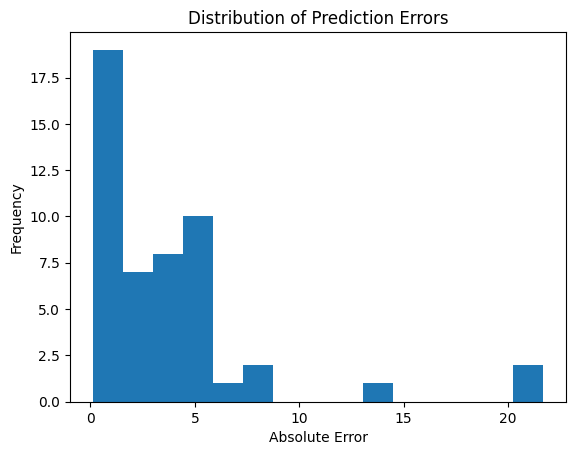

In [51]:
import matplotlib.pyplot as plt

df["error"] = abs(df["truth"] - df["prediction"])

plt.hist(df["error"], bins=15)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()

# What the histogram shows:

1- Most errors are between 0 and 5

2- A few errors are between 5 and 8

3- There are 2 very large outliers (~14 and ~21)


The histogram of absolute errors shows that most predictions have an error between 0 and 5 (in $1000 units). This means the model typically predicts house prices within $5000 of the true value. However, a small number of extreme errors (above 10) are present. These correspond to expensive houses, where the model underestimates the price. This indicates that the model performs well for mid-range houses but struggles with extreme values.